In [29]:
from utils import *
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy import stats
import seaborn as sns

from scipy import interpolate

#from intercept_ransac import *
#


In [30]:
dfuplow = process_roi_txt_to_excel("lowupbranch.txt", "lowupbranch.xlsx")
dfuplow = dfuplow.iloc[:]

dfside = process_roi_txt_to_excel("sidebranch.txt", "sidebranch.xlsx")
dfside = dfside.iloc[:]


xiuplow=list(dfuplow.columns)
xiuplow = np.array(xiuplow)[[3,4,5,6,11,12,13,14]]
t=dfuplow.index.to_numpy()

data_cor_uplow=dfuplow[xiuplow].to_numpy(dtype=float)

data_unc_uplow=dfuplow[xiuplow].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

xiside=list(dfside.columns)
xiside = xiside[1:5]
xi_side = xiside
t=dfside.index.to_numpy()


data_side_cor=dfside[xiside].to_numpy(dtype=float)

data_side_unc=dfside[xiside].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))



xi_up_end = np.array(xiuplow)[3]
xi_up = np.array(xiuplow)[0:4]-np.array(xiuplow)[0]
xi_low_start = np.array(xiuplow)[4]
xi_low = np.array(xiuplow)[4:]-np.array(xiuplow)[4]

xi_side = np.array(xi_side)-xi_side[0]

data_up_cor = data_cor_uplow[:, 0:4]
data_up_unc = data_unc_uplow[:, 0:4]

data_low_cor = data_cor_uplow[:, 4:]
data_low_unc = data_unc_uplow[:, 4:]


In [31]:
t

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
       165., 170., 175., 180., 185., 190., 195., 200., 205.])

In [32]:
steps=len(data_up_unc)

d_up_xi=[]

for i in range(1,len(xi_up)):
     d_up_xi.append(float(xi_up[i])-float(xi_up[i-1]))


In [33]:
steps=len(data_side_unc)

d_side_xi=[]

for i in range(1,len(xi_side)):
     d_side_xi.append(float(xi_side[i])-float(xi_side[i-1]))


In [34]:
steps=len(data_low_unc)

d_low_xi=[]

for i in range(1,len(xi_low)):
     d_low_xi.append(float(xi_low[i])-float(xi_low[i-1]))


In [35]:
df_up = pd.DataFrame(data_up_cor, columns=xi_up)
df_low = pd.DataFrame(data_low_cor, columns=xi_low)
df_side = pd.DataFrame(data_side_cor, columns=xi_side)

In [36]:
xi_side

array([ 0.   , 11.744, 23.488, 35.23 ])

In [37]:
df_side

,0.000,11.744,23.488,35.230
0,118.322619,130.929216,135.158640,140.672003
1,178.281714,192.724858,209.606117,236.830544
2,163.386006,178.458188,189.858761,208.529515
3,162.657838,175.108431,176.419012,194.712786
4,158.500232,168.398433,189.961843,199.865308
5,215.894203,225.307389,230.531760,238.049420
6,376.312926,386.222312,336.452185,323.590928
7,803.049988,753.000173,555.516299,470.539997
8,1995.145922,1405.172729,930.877909,750.012920
9,5012.227682,3055.617451,1615.132687,1142.733264


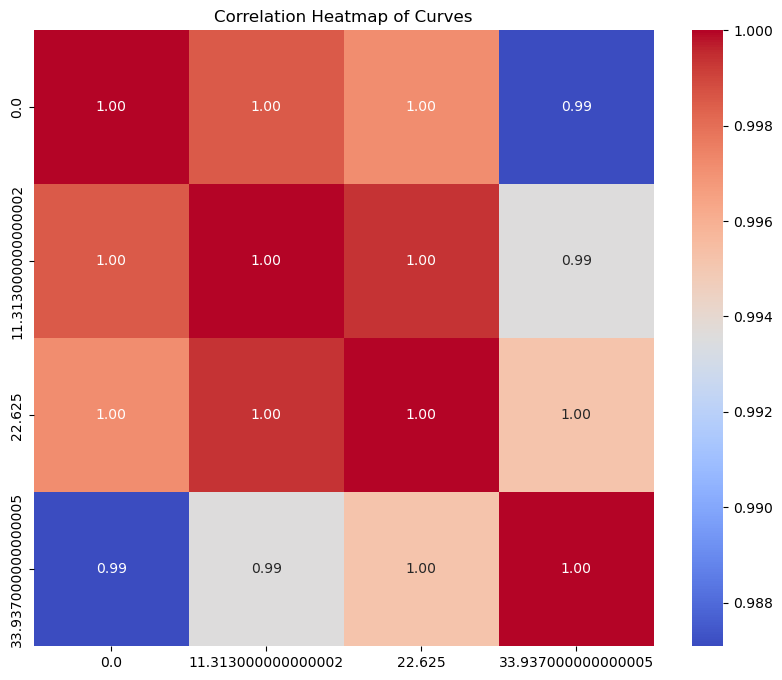

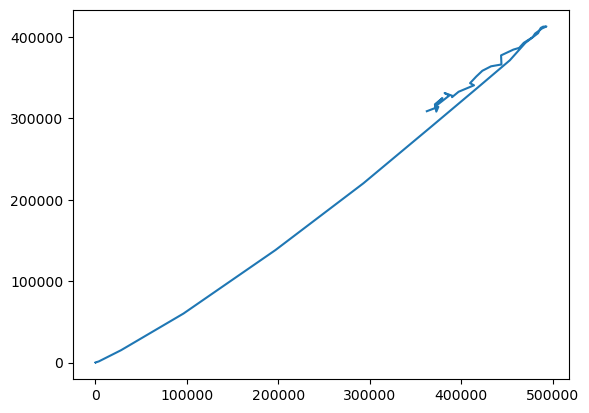

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_up[xi_up[:]].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_up_cor[:,0],data_up_cor[:,1])

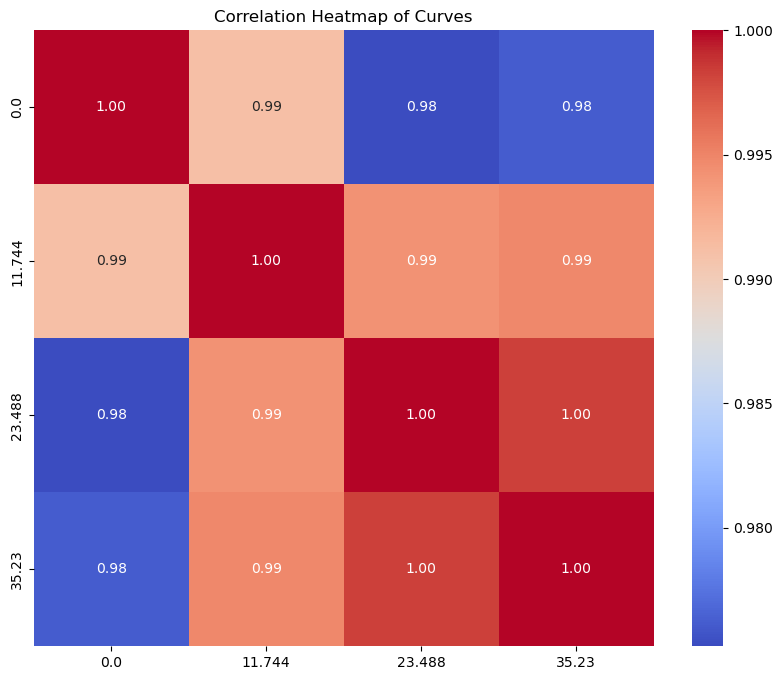

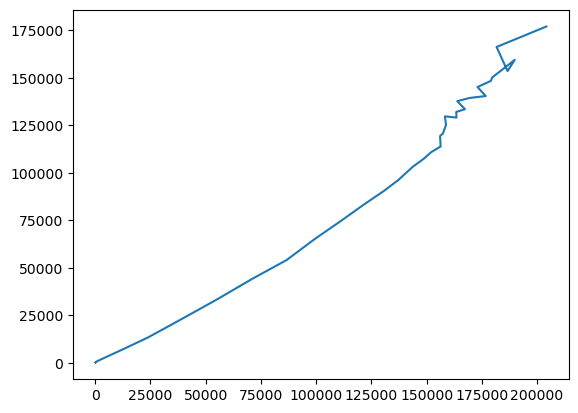

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_side[xi_side[:]].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_side_cor[:,0],data_side_cor[:,1])

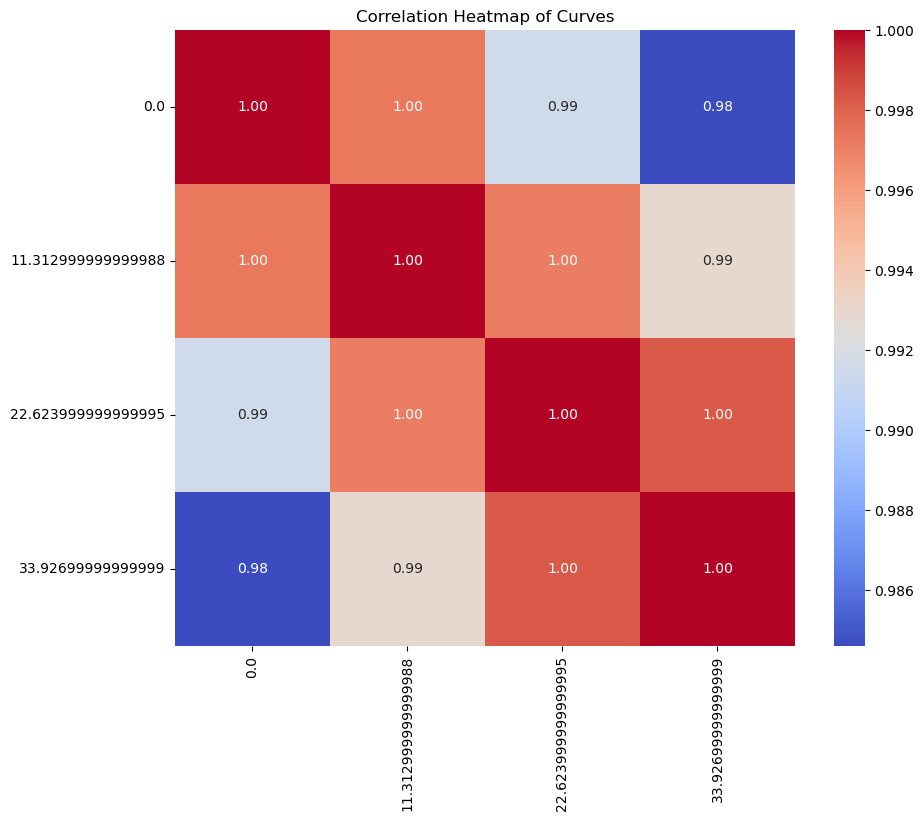

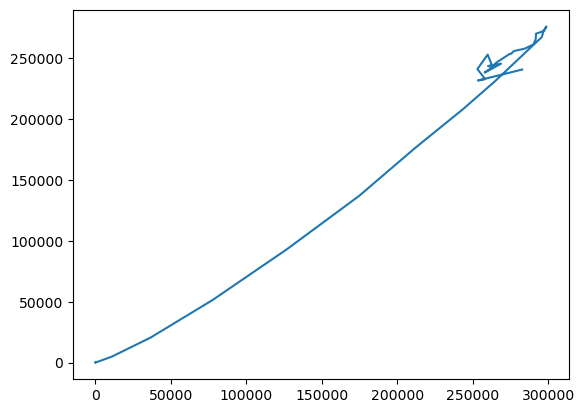

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_low[xi_low[:]].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_low_cor[:,0],data_low_cor[:,1])

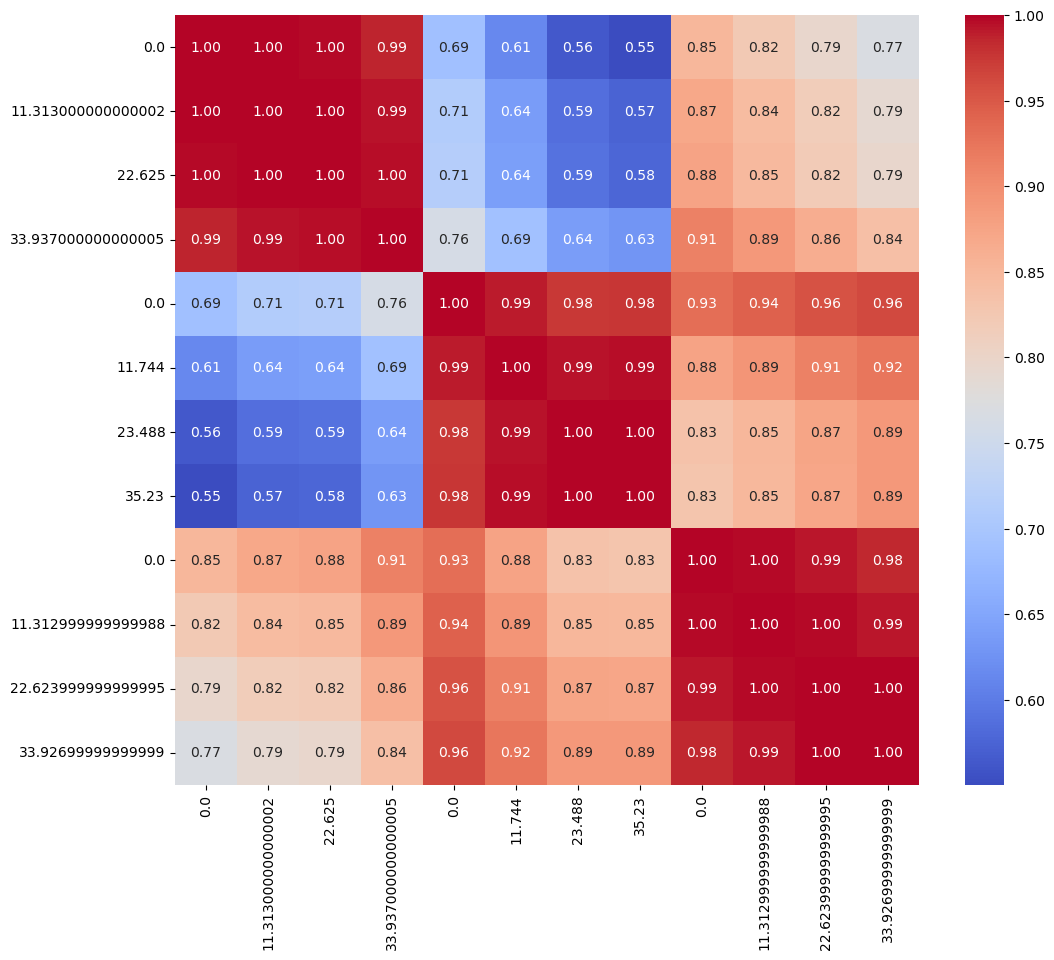

In [41]:
# Step 1: Concatenate the dataframes along the columns
df_combined = pd.concat([df_up[xi_up[:]], df_side[xi_side[:]], df_low[xi_low[:]]], axis=1)

# Step 2: Compute the correlation matrix for the concatenated dataframe
combined_corr = df_combined.corr(method="pearson")

# Step 3: Plot the combined heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(combined_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("")
plt.show()

In [42]:
df_combined

,0.000,11.313,22.625,33.937,0.000,11.744,23.488,35.230,0.000,11.313,22.624,33.927
0,142.569065,134.417903,117.392815,110.373846,118.322619,130.929216,135.158640,140.672003,85.051519,84.231640,93.219487,91.472584
1,224.666764,204.481048,180.966077,168.261147,178.281714,192.724858,209.606117,236.830544,140.930091,116.682083,125.769471,100.966229
2,183.687425,177.744051,164.876307,166.479271,163.386006,178.458188,189.858761,208.529515,118.544421,117.174283,112.311701,118.694441
3,191.769538,173.217923,159.863658,148.311726,162.657838,175.108431,176.419012,194.712786,130.998406,130.886006,122.397572,152.239793
4,233.222833,190.141398,178.722052,163.395910,158.500232,168.398433,189.961843,199.865308,147.920408,115.101565,132.253925,132.778237
5,3615.790593,1372.489232,429.700690,221.645342,215.894203,225.307389,230.531760,238.049420,151.185721,153.513531,164.546284,174.317716
6,28002.308283,15174.040181,8737.473082,3406.763371,376.312926,386.222312,336.452185,323.590928,170.705596,188.795024,168.549583,199.972986
7,96385.862833,60262.955151,41108.479198,19977.289403,803.049988,753.000173,555.516299,470.539997,299.172237,197.070998,223.094400,199.374707
8,196993.937980,138259.805535,107130.147386,64255.286899,1995.145922,1405.172729,930.877909,750.012920,1999.605717,872.260284,401.663960,276.242300
9,293055.283064,220168.246110,184952.364081,130435.852952,5012.227682,3055.617451,1615.132687,1142.733264,10899.081248,4899.234933,2454.946105,1109.933140


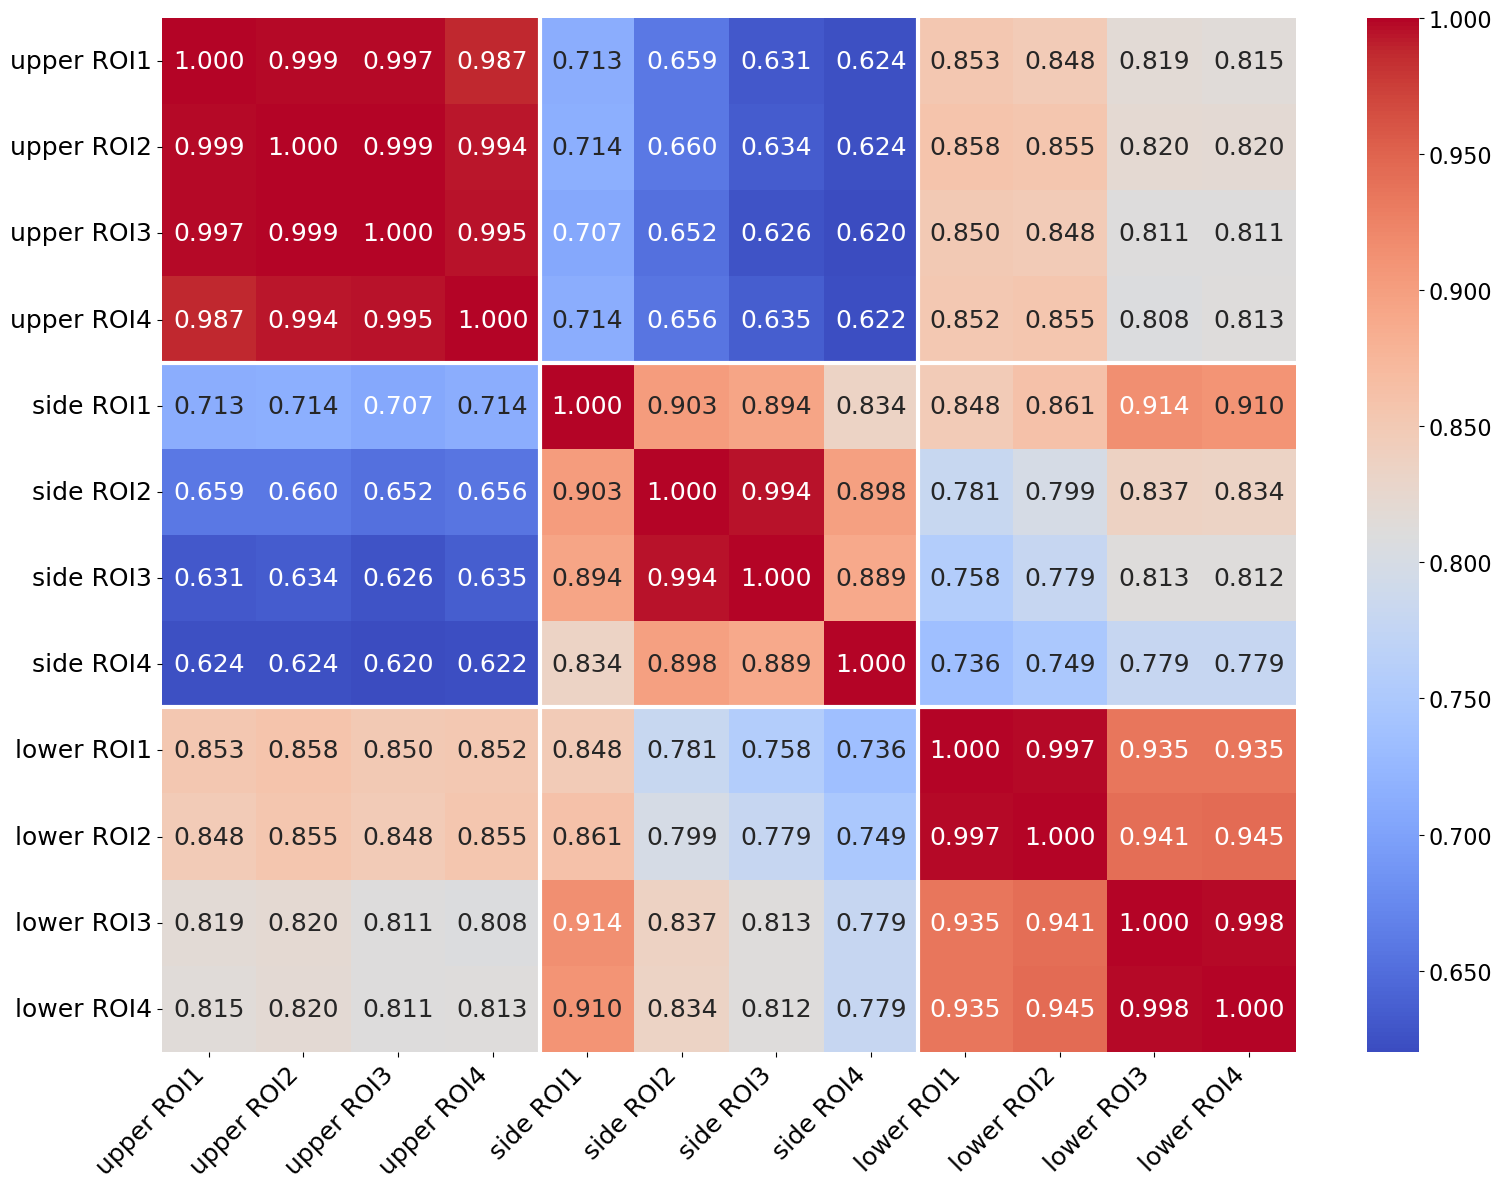

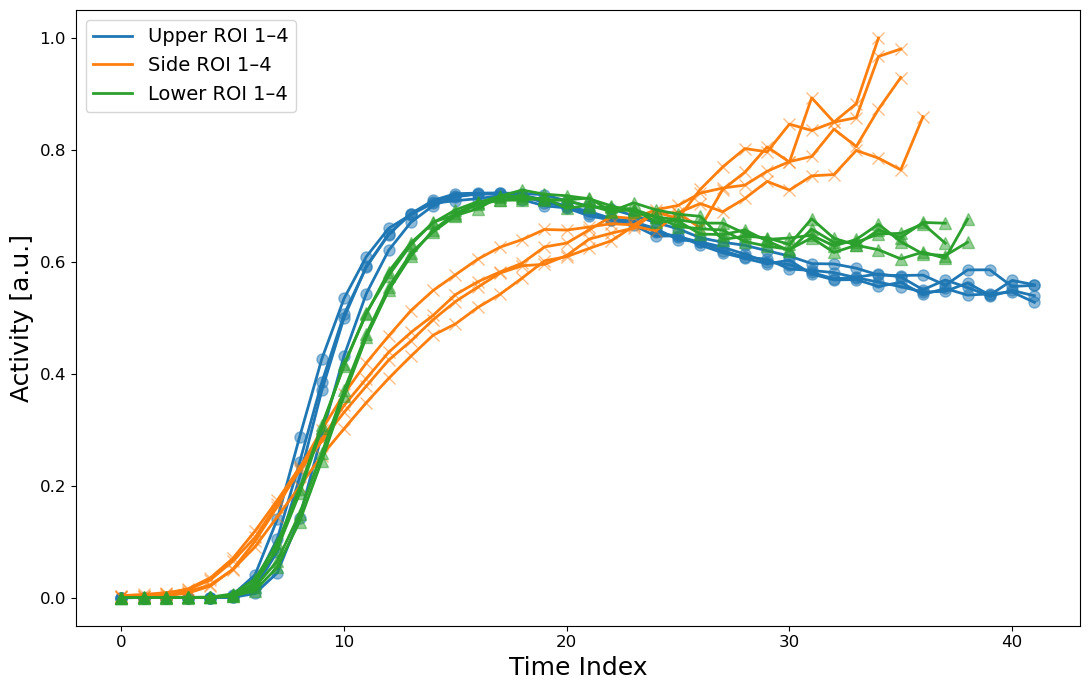

Optimal shifts (Δt) and scales:
  upper ROI1: Δt =   0.000, scale =   1.000
  upper ROI2: Δt =  -0.000, scale =   1.200
  upper ROI3: Δt =  -0.000, scale =   1.375
  upper ROI4: Δt =  -0.000, scale =   1.530
   side ROI1: Δt =   5.000, scale =   2.889
   side ROI2: Δt =   6.000, scale =   3.604
   side ROI3: Δt =   6.000, scale =   4.693
   side ROI4: Δt =   7.000, scale =   5.413
  lower ROI1: Δt =   3.000, scale =   1.644
  lower ROI2: Δt =   3.000, scale =   1.810
  lower ROI3: Δt =   4.000, scale =   1.927
  lower ROI4: Δt =   4.000, scale =   2.093


In [43]:
# ====================
# 📦 IMPORTS
# ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from scipy.optimize import differential_evolution

# ====================
# 📄 LOAD AND PREP DATA
# ====================
# Use df_combined exactly as built (order: upper[4], side[4], lower[4])
data = df_combined.copy()

# If columns are a MultiIndex, flatten them (preserves order)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [" | ".join(map(str, lev)).strip() for lev in data.columns.values]

n_cols = data.shape[1]
assert n_cols >= 12, f"Expected at least 12 columns (upper/side/lower × 4), got {n_cols}"

# Keep first 12 columns in that order
data = data.iloc[:, :12].copy()

# Pretty display names ONLY (do not use for selection)
pretty_names = (
    [f"upper ROI{i+1}" for i in range(4)] +
    [f"side ROI{i+1}"  for i in range(4)] +
    [f"lower ROI{i+1}" for i in range(4)]
)

# ====================
# 🧠 FUNCTION DEFINITIONS
# ====================
def shift_curve_interp(curve, shift, target_len):
    """Shift with linear interpolation; out-of-range -> 0.0 (not NaN)."""
    x = np.arange(len(curve))
    f = interp1d(x, curve, kind="linear", bounds_error=False, fill_value=0.0)
    return f(np.arange(target_len) + shift)

def optimize_shift_and_scale(curve, reference, search_bounds=(-10, 15), scale_bounds=(0.1, 15.0)):
    """Find optimal (time shift, amplitude scale) to align curve to reference, with overlap/shift penalties."""
    ref = np.asarray(reference, dtype=float)
    cur = np.asarray(curve, dtype=float)

    def nz_frac(a):
        return (np.abs(a) > 0).mean()

    def loss_fn(params):
        shift, scale = params
        shifted = shift_curve_interp(cur, shift, len(ref)) * scale

        # Weighted SSE (emphasize early half)
        w = np.ones_like(ref, dtype=float)
        w[: len(ref)//2] *= 2.0
        w /= w.sum()
        loss = float(np.sum(w * (shifted - ref) ** 2))

        # Penalty: encourage sufficient non-zero overlap (≥20%)
        overlap_quality = max(nz_frac(shifted), 1e-6)
        loss += 1e3 * (0.2 - min(overlap_quality, 0.2))

        # Penalty: discourage extreme shifts (soft quadratic)
        mid = 0.5 * (search_bounds[0] + search_bounds[1])
        span = max(search_bounds[1] - search_bounds[0], 1e-6)
        loss += 10.0 * ((shift - mid) / span) ** 2

        return loss

    result = differential_evolution(
        loss_fn,
        bounds=[search_bounds, scale_bounds],
        polish=True,
        tol=1e-6,
        maxiter=200
    )
    return result.x  # (best_shift, best_scale)

# --- helper: mask ONLY trailing zero/near-zero edges for plotting ---
def mask_trailing_for_plot(s: pd.Series, frac_threshold=0.01):
    """
    Return an array where trailing samples below a per-curve threshold are set to NaN
    so the padded tail doesn’t draw as a flat line. Leading zeros are kept.
    Threshold = frac_threshold * curve_max (default 1% of its own max).
    """
    a = s.to_numpy(dtype=float).copy()
    if not np.isfinite(a).any():
        return np.full_like(a, np.nan)

    thr = max(frac_threshold * np.nanmax(a), 1e-12)
    nz = np.flatnonzero(a > thr)
    if nz.size == 0:
        # entire curve below threshold → nothing to draw
        return np.full_like(a, np.nan)
    last = nz[-1]
    a[last + 1 :] = np.nan  # mask only the tail
    return a

# ====================
# ⚙️ ALIGNMENT
# ====================
aligned_curves = {}
shifts = {}

# Use first column as reference
ref_curve = data.iloc[:, 0].to_numpy(dtype=float)
aligned_curves[pretty_names[0]] = ref_curve
shifts[pretty_names[0]] = (0.0, 1.0)

for disp_name, col_idx in zip(pretty_names[1:], range(1, 12)):
    raw = data.iloc[:, col_idx].to_numpy(dtype=float)
    sft, scl = optimize_shift_and_scale(raw, ref_curve)
    aligned_curves[disp_name] = shift_curve_interp(raw, sft, len(ref_curve)) * scl
    shifts[disp_name] = (sft, scl)

aligned_data = pd.DataFrame(aligned_curves)

# Normalize for plotting (global max)
aligned_data = aligned_data / aligned_data.max().max()

# ====================
# 📈 Correlation heatmap with group dividers
# ====================
corr_matrix = aligned_data.corr(method="pearson", min_periods=4)
plt.figure(figsize=(16, 12))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    annot_kws={"size": 18},
    cbar_kws={"format": "%.3f"}
)
plt.xticks(fontsize=18, rotation=45, ha="right")
plt.yticks(fontsize=18, rotation=0)
# Resize colorbar label font and ticks

colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=16)

# draw separators between groups (after 4 and 8)
for b in [4, 8]:
    ax.axvline(b, color="white", lw=3)
    ax.axhline(b, color="white", lw=3)

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.title("", fontsize=18)
plt.tight_layout()
plt.show()

# ====================
# 📉 Grouped line plots with tail masking and clean legend
# ====================
# Create a plot-only masked view (mask trailing only; keep leading zeros)
plot_data = pd.DataFrame({
    col: mask_trailing_for_plot(aligned_data[col], frac_threshold=0.01)
    for col in aligned_data.columns
})

dt = 1.0  # minutes per frame (adjust if you have a true time vector)
time = np.arange(plot_data.shape[0]) * dt

plt.style.use('default')
plt.figure(figsize=(11, 7))
plt.xlabel("Time Index", fontsize=18)
plt.ylabel("Activity [a.u.]", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Helper to plot a 2D array with a single legend entry
def plot_group(mat, color, label, marker=None):
    # plot first line with label, rest without
    plt.plot(time, mat[:, 0], color=color, linewidth=2, label=label)
    for j in range(1, mat.shape[1]):
        plt.plot(time, mat[:, j], color=color, linewidth=2, label="_nolegend_")
    if marker is not None:
        plt.plot(time, mat[:, 0], marker, color=color, markersize=8, alpha=0.5, markevery=1, label="_nolegend_")
        for j in range(1, mat.shape[1]):
            plt.plot(time, mat[:, j], marker, color=color, markersize=8, alpha=0.5, markevery=1, label="_nolegend_")

upper = plot_data.iloc[:, 0:4].to_numpy()
side  = plot_data.iloc[:, 4:8].to_numpy()
lower = plot_data.iloc[:, 8:12].to_numpy()

plot_group(upper, colors[0], "Upper ROI 1–4", marker='o')
plot_group(side,  colors[1], "Side ROI 1–4",  marker='x')
plot_group(lower, colors[2], "Lower ROI 1–4", marker='^')

plt.legend(fontsize=14, frameon=True)
plt.tight_layout()
plt.show()

# ====================
# 📝 Inspect optimal shifts/scales (optional)
# ====================
print("Optimal shifts (Δt) and scales:")
for k, (sft, scl) in shifts.items():
    print(f"{k:>12}: Δt = {sft:7.3f}, scale = {scl:7.3f}")

Selected columns: ['upper ROI1', 'upper ROI2', 'upper ROI3', 'upper ROI4', 'side ROI1', 'side ROI2', 'side ROI3', 'side ROI4', 'lower ROI1', 'lower ROI2', 'lower ROI3', 'lower ROI4']
Reference shape: (42,)
col='upper ROI1', shape=(42,), type=<class 'pandas.core.series.Series'>
col='upper ROI2', shape=(42,), type=<class 'pandas.core.series.Series'>
col='upper ROI3', shape=(42,), type=<class 'pandas.core.series.Series'>
col='upper ROI4', shape=(42,), type=<class 'pandas.core.series.Series'>
col='side ROI1', shape=(42,), type=<class 'pandas.core.series.Series'>
col='side ROI2', shape=(42,), type=<class 'pandas.core.series.Series'>
col='side ROI3', shape=(42,), type=<class 'pandas.core.series.Series'>
col='side ROI4', shape=(42,), type=<class 'pandas.core.series.Series'>
col='lower ROI1', shape=(42,), type=<class 'pandas.core.series.Series'>
col='lower ROI2', shape=(42,), type=<class 'pandas.core.series.Series'>
col='lower ROI3', shape=(42,), type=<class 'pandas.core.series.Series'>
col='l

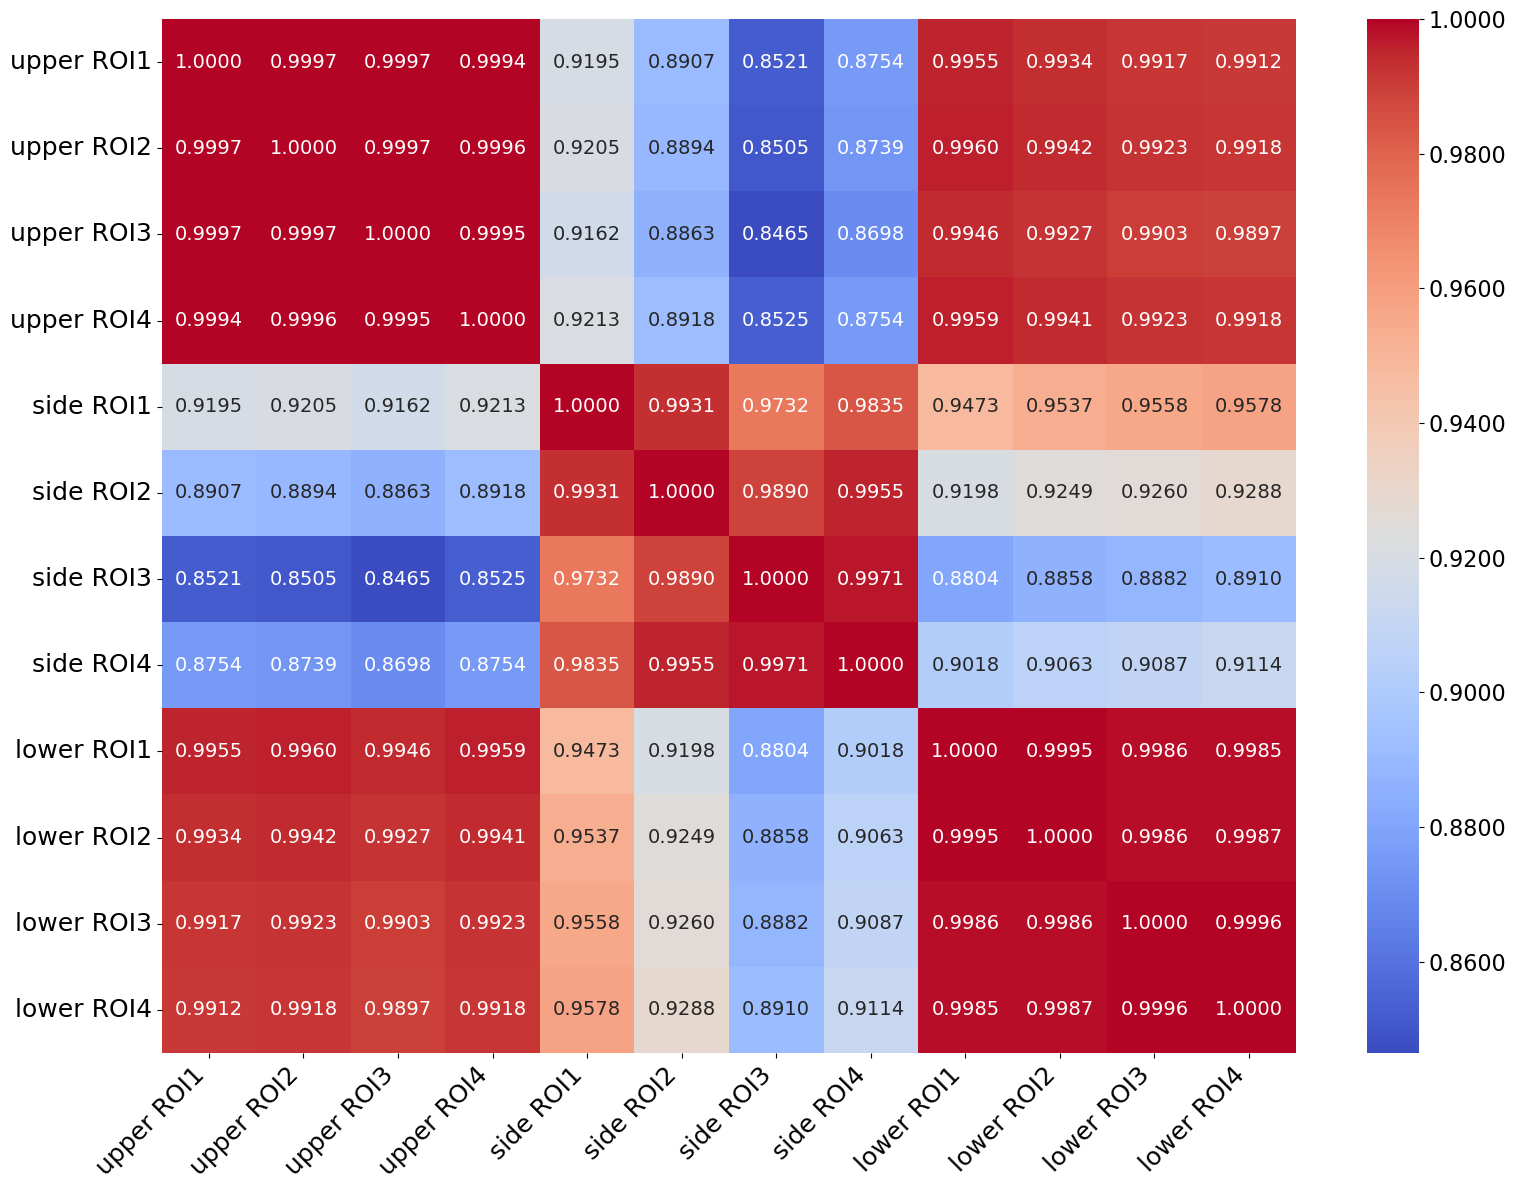

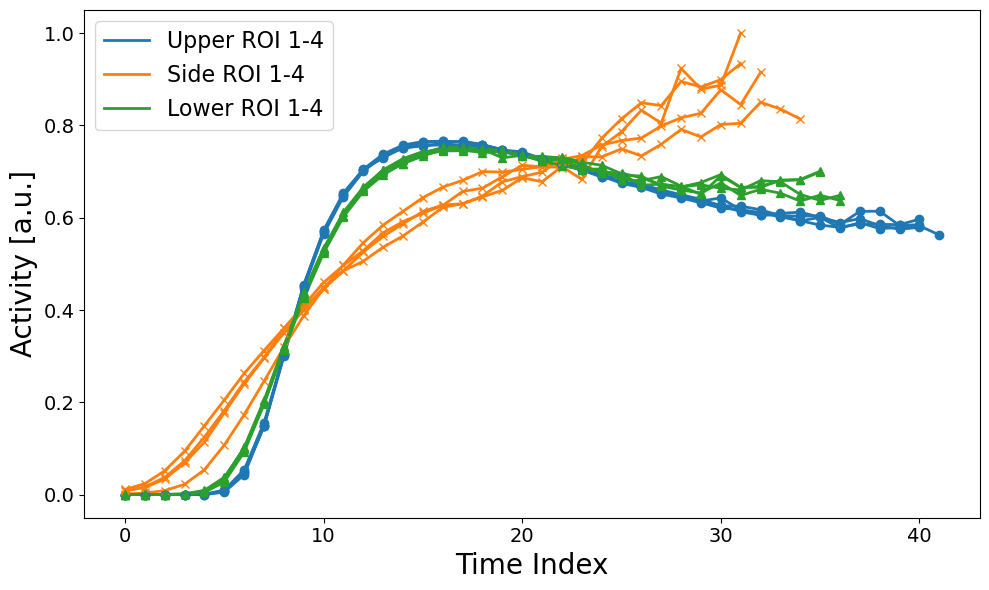

In [78]:
# ====================
# 📦 IMPORTS
# ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from scipy.optimize import minimize, differential_evolution
from scipy.stats import pearsonr

# ====================
# 📄 LOAD AND PREP DATA
# ====================
data = df_combined.copy()

# Rename columns for disambiguation
group_prefixes = ['upper', 'side', 'lower']
columns_per_group = 4
new_columns = [f"{group} ROI{i+1}" for group in group_prefixes for i in range(columns_per_group)]
data.columns = new_columns

# Define groups
xi_upper = ['upper ROI1', 'upper ROI2', 'upper ROI3', 'upper ROI4']
xi_sides  = ['side ROI1', 'side ROI2', 'side ROI3', 'side ROI4']
xi_lower = ['lower ROI1', 'lower ROI2', 'lower ROI3', 'lower ROI4']

# ====================
# 🧠 FUNCTION DEFINITIONS
# ====================
def shift_curve_interp(curve, shift, target_len):
    """
    Shift curve by a (possibly fractional) amount using interpolation.
    Fills out-of-bounds values with NaN.
    """
    x = np.arange(len(curve))
    interpolator = interp1d(x, curve, kind='linear', bounds_error=False, fill_value=np.nan)
    x_shifted = np.arange(target_len) + shift
    return interpolator(x_shifted)

def optimize_shift_and_scale(curve, reference, search_bounds=(-10, 15), scale_bounds=(0.1, 15.0)):
    """
    Find optimal (time shift, amplitude scale) to align curve to reference.
    """
    def loss_fn(params):
        shift, scale = params
        shifted = shift_curve_interp(curve, shift, len(reference)) * scale

        valid = ~np.isnan(shifted) & ~np.isnan(reference)
        if np.sum(valid) < 2:
            print(f"Too few valid points for shift={shift:.2f}, scale={scale:.2f}")
            return np.inf

        residuals = (shifted - reference) ** 2
        weights = np.ones(len(reference))
        weights[:len(reference) // 2] *= 2.0
        weights = weights[valid]
        residuals = residuals[valid]

        weights /= np.sum(weights)
        loss = np.sum(weights * residuals)

        print(f"shift={shift:.2f}, scale={scale:.2f}, loss={loss:.4f}")
        return loss

    bounds = [search_bounds, scale_bounds]
    result = differential_evolution(loss_fn, bounds)
    return result.x  # (best_shift, best_scale)

# ====================
# 📊 DATA SELECTION
# ====================
selected_cols = xi_upper + xi_sides + xi_lower
custom_names = new_columns#[f"ROI{i+1}" for i in range(len(selected_cols))]

print("Selected columns:", selected_cols)
print("Reference shape:", data[selected_cols[0]].shape)

for col in selected_cols:
    val = data[col]
    print(f"{col=}, shape={val.shape}, type={type(val)}")

# ====================
# ⚙️ ALIGNMENT
# ====================
aligned_curves = {}
shifts = {}

# Use unscaled reference (first curve)
ref_curve = data[selected_cols[0]].to_numpy(dtype=float)
aligned_curves[custom_names[0]] = ref_curve
shifts[custom_names[0]] = (0.0, 1.0)

for name, col in zip(custom_names[1:], selected_cols[1:]):
    curve = data[col].to_numpy(dtype=float)

    opt_shift, opt_scale = optimize_shift_and_scale(curve, ref_curve)
    aligned = shift_curve_interp(curve, opt_shift, len(ref_curve)) * opt_scale

    aligned_curves[name] = aligned
    shifts[name] = (opt_shift, opt_scale)

aligned_data = pd.DataFrame(aligned_curves)
aligned_data = aligned_data / aligned_data.max().max()

# ====================
# 📈 PLOTS
# ====================
print("Optimal shifts (time, scale):")
for name, (shift, scale) in shifts.items():
    print(f"{name}: Δt = {shift:.2f}, scale = {scale:.3f}")

plt.figure(figsize=(16, 12))

# Compute correlation separately to reformat colorbar later
corr_matrix = aligned_data.corr(method="pearson", min_periods=4)

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    annot_kws={"size": 14},
    cbar_kws={"format": "%.4f"}  # Format colorbar to 4 decimal places
)

# Increase font size of tick labels
plt.xticks(fontsize=18, rotation=45, ha="right")
plt.yticks(fontsize=18, rotation=0)

# Resize colorbar label font and ticks
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=16)

plt.title("", fontsize=20)
plt.tight_layout()
plt.savefig("poplar_branch_pearson.pdf", format="pdf")  
plt.show()

# Assume 1 minute per time point
dt = 1.0  # or use your actual time vector if available
time = np.arange(aligned_data.shape[0]) * dt

# Split by ROI group (3 per group)
exp_data_upper = aligned_data.iloc[:, 0:4].values
exp_data_side = aligned_data.iloc[:, 4:8].values
exp_data_lower = aligned_data.iloc[:, 8:12].values

plt.style.use('default')
plt.figure(figsize=(10, 6))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.xlabel("Time Index", fontsize=20)
plt.ylabel("Activity [a.u.]", fontsize=20)

# Match simulation plot style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot experimental data as lines
plt.plot(time, exp_data_upper, color=colors[0], label="Upper ROI 1-4", linewidth=2)
plt.plot(time, exp_data_side, color=colors[1], label="Side ROI 1-4", linewidth=2)
plt.plot(time, exp_data_lower, color=colors[2], label="Lower ROI 1-4", linewidth=2)

# Optional: also overlay with markers
plt.plot(time, exp_data_upper, 'o', color=colors[0], markersize=6)
plt.plot(time, exp_data_side, 'x', color=colors[1], markersize=6)
plt.plot(time, exp_data_lower, '^', color=colors[2], markersize=6)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), fontsize=16)

plt.tight_layout()
plt.savefig("poplar_branch_aligned.pdf", format="pdf")  
plt.show()




In [45]:
df_combined

,0.000,11.313,22.625,33.937,0.000,11.744,23.488,35.230,0.000,11.313,22.624,33.927
0,142.569065,134.417903,117.392815,110.373846,118.322619,130.929216,135.158640,140.672003,85.051519,84.231640,93.219487,91.472584
1,224.666764,204.481048,180.966077,168.261147,178.281714,192.724858,209.606117,236.830544,140.930091,116.682083,125.769471,100.966229
2,183.687425,177.744051,164.876307,166.479271,163.386006,178.458188,189.858761,208.529515,118.544421,117.174283,112.311701,118.694441
3,191.769538,173.217923,159.863658,148.311726,162.657838,175.108431,176.419012,194.712786,130.998406,130.886006,122.397572,152.239793
4,233.222833,190.141398,178.722052,163.395910,158.500232,168.398433,189.961843,199.865308,147.920408,115.101565,132.253925,132.778237
5,3615.790593,1372.489232,429.700690,221.645342,215.894203,225.307389,230.531760,238.049420,151.185721,153.513531,164.546284,174.317716
6,28002.308283,15174.040181,8737.473082,3406.763371,376.312926,386.222312,336.452185,323.590928,170.705596,188.795024,168.549583,199.972986
7,96385.862833,60262.955151,41108.479198,19977.289403,803.049988,753.000173,555.516299,470.539997,299.172237,197.070998,223.094400,199.374707
8,196993.937980,138259.805535,107130.147386,64255.286899,1995.145922,1405.172729,930.877909,750.012920,1999.605717,872.260284,401.663960,276.242300
9,293055.283064,220168.246110,184952.364081,130435.852952,5012.227682,3055.617451,1615.132687,1142.733264,10899.081248,4899.234933,2454.946105,1109.933140


In [46]:
def plot_all_columns(data_array):
    """
    Function to plot all columns in a 2D array. Each column is stored 
    in a dynamically created variable named roi1, roi2, ..., roiN.

    Parameters:
    data_array (ndarray): 2D array where each column is a separate dataset to plot.
    """
    # Dictionary to hold dynamically created variables
    roi_dict = {}
    
    # Extract the first column and compute its maximum
    roi1_max = np.max(data_array[:, 0])
    
    # Loop through columns in the data array
    for i in range(data_array.shape[1]):
        # Dynamically name the variable
        var_name = f'roi{i+1}'
        roi_dict[var_name] = data_array[:, i] / roi1_max  # Normalize by roi1 max
        
        # Plot the normalized column
        plt.plot(roi_dict[var_name], label=var_name)
    
    # Add legend and labels
    plt.legend()
    plt.xlabel('Index')
    plt.ylabel('Normalized Value')
    plt.title('Normalized Plots of All Columns')
    plt.show()
    
    return roi_dict  # Return dictionary of normalized variables

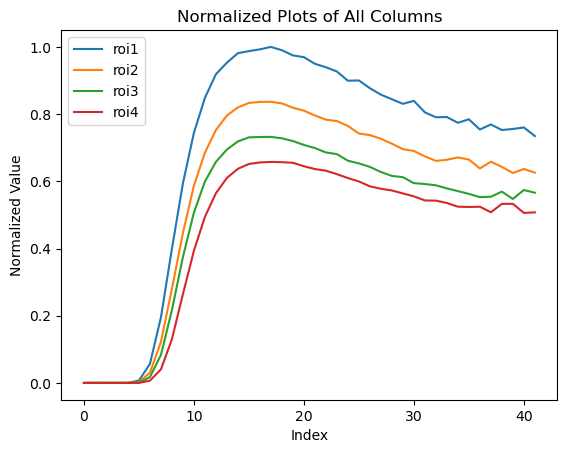

In [47]:
rois_up = plot_all_columns(data_up_cor)

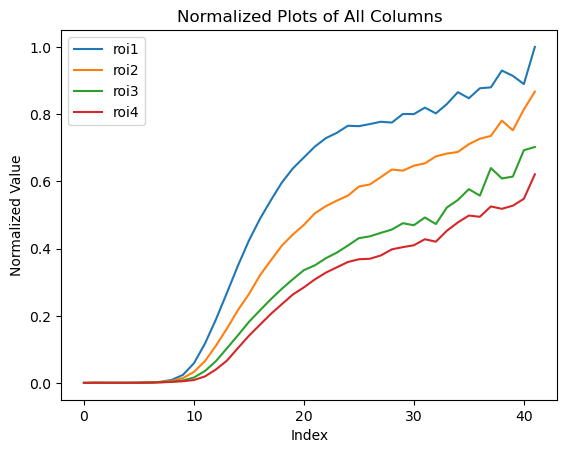

In [48]:
rois_side = plot_all_columns(data_side_cor)


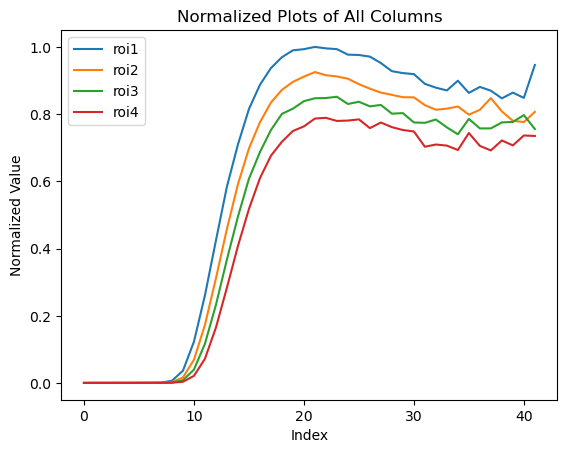

In [49]:
rois_low = plot_all_columns(data_low_cor)

In [50]:
rois_up

{'roi1': array([2.89069260e-04, 4.55528381e-04, 3.72439758e-04, 3.88826837e-04,
        4.72876440e-04, 7.33128125e-03, 5.67767387e-02, 1.95429423e-01,
        3.99419692e-01, 5.94191131e-01, 7.44661877e-01, 8.48531665e-01,
        9.18846528e-01, 9.53148985e-01, 9.81375044e-01, 9.87497852e-01,
        9.92750967e-01, 1.00000000e+00, 9.90219374e-01, 9.74790425e-01,
        9.69573310e-01, 9.49781504e-01, 9.39551126e-01, 9.26823436e-01,
        8.99437555e-01, 9.00261487e-01, 8.77171284e-01, 8.57987985e-01,
        8.44278513e-01, 8.30669366e-01, 8.39427309e-01, 8.05352017e-01,
        7.90674079e-01, 7.91343772e-01, 7.74233762e-01, 7.84658691e-01,
        7.54283777e-01, 7.69335567e-01, 7.52784577e-01, 7.55872122e-01,
        7.60385283e-01, 7.34842847e-01]),
 'roi2': array([2.72542180e-04, 4.14600358e-04, 3.60389131e-04, 3.51212073e-04,
        3.85525663e-04, 2.78282282e-03, 3.07664820e-02, 1.22187572e-01,
        2.80331920e-01, 4.46407305e-01, 5.87412890e-01, 6.85583911e-01,
      

In [51]:
xi_side

array([ 0.   , 11.744, 23.488, 35.23 ])

In [84]:
def process_and_plot_rois(rois, t):
    """
    Processes and plots multiple ROIs from a dictionary using cubic spline interpolation and calculates max ratios.

    Parameters:
    - rois (dict): Dictionary where keys are ROI names (e.g., 'roi1', 'roi2') and values are 1D arrays of data.
    - t (array): Time array corresponding to the ROIs.

    Returns:
    - results (dict): Dictionary where keys are ROI names and values are a dictionary with:
        - 'cubic_spline': The cubic spline object for the ROI.
        - 'max_value': Maximum value of the interpolated data.
        - 'half_max': Half-maximum value of the interpolated data.
        - 'roots': Roots of the cubic spline.
        - 'ratios': List of ratios between consecutive max values (calculated for all ROIs together).
    """
    results = {}
    maxima = []
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    plt.figure()
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    for i, (roi_name, roi_data) in enumerate(rois.items()):
        # Interpolate using Cubic Spline
        
        cu = interpolate.CubicSpline(t.ravel(), roi_data.ravel())
        x_interp = np.linspace(0, max(t), 500)
        y_interp = cu(x_interp)

        # Compute max and half-max
        max_value = np.max(y_interp)
        half_max = max_value / 2
        maxima.append(max_value)

        # Plot interpolated curve
        color = colors[i % len(colors)]
        plt.plot(x_interp, y_interp, 'k', linewidth=1.2, label="Spline")

        # Highlight max and half-max
        plt.hlines(max_value, -9, max(t)+10, linestyle=(0, (1, 1)), color=color, label="Maximum")
        plt.hlines(half_max, -9, max(t)+10, linestyle='--', color=color, label="Half-Maximum")

        # Plot the original points
        plt.plot(t, roi_data, marker='.', markersize=8, linestyle='none', color=color, label="Experimental Data")

        # Save results
        results[roi_name] = {
            'cubic_spline': cu,
            'max_value': max_value,
            'half_max': half_max,
            'roots': cu.roots()
        }
    
    # Compute ratios of maxima
    ratios = [maxima[i] / maxima[i + 1] for i in range(len(maxima) - 1)]

    # Add ratios to results
    results['ratios'] = ratios

    plt.xlabel("Time [min]", fontsize=15)
    plt.ylabel("Activity [a.u.]", fontsize=15)
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=12, )    
    
    plt.savefig("lowcor.pdf", format="pdf")  
    plt.show()
    
   
    
    return results

In [80]:
def find_roots(x, y):
    s = np.abs(np.diff(np.sign(y))).astype(bool)
    return x[:-1][s] + np.diff(x)[s] / (np.abs(y[1:][s] / y[:-1][s]) + 1)

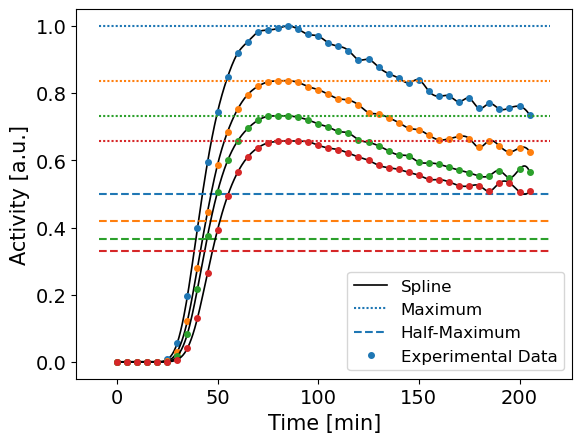

In [81]:
results_up=process_and_plot_rois(rois_up,t)

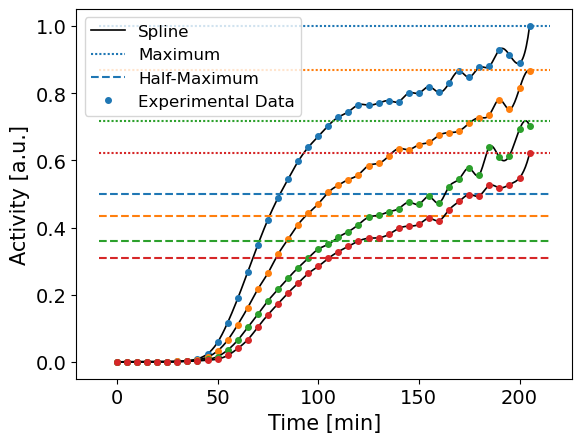

In [83]:
results_side=process_and_plot_rois(rois_side,t)

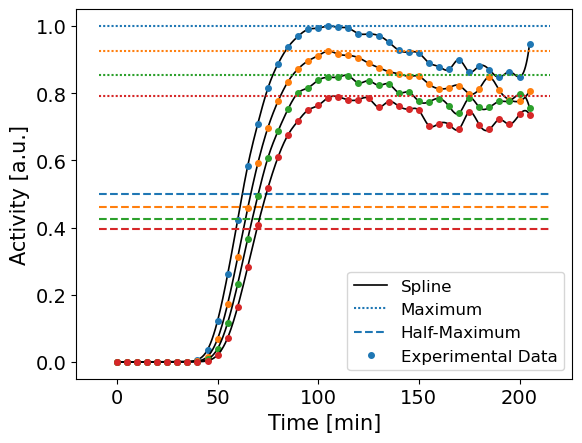

In [85]:
results_low=process_and_plot_rois(rois_low,t)

In [57]:
def compute_hmax_times(results, time_range):
    """
    Computes the half-max times for each ROI in the results using the find_roots function.

    Parameters:
    - results (dict): Dictionary containing ROI results with cubic splines and half-max values.
    - time_range (array): Array of time values to use for interpolation (e.g., np.linspace).

    Returns:
    - hmax_times (dict): Dictionary with ROI names as keys and the first half-max time as values.
    """
    def find_roots(x, y):
        """
        Finds the roots of a signal crossing zero using interpolation.
        """
        s = np.abs(np.diff(np.sign(y))).astype(bool)
        return x[:-1][s] + np.diff(x)[s] / (np.abs(y[1:][s] / y[:-1][s]) + 1)

    hmax_times = {}

    for roi_name, data in results.items():
        if roi_name == "ratios":  # Skip the "ratios" key if present
            continue
        
        # Extract the cubic spline and half-max value
        cubic_spline = data['cubic_spline']
        half_max = data['half_max']
        
        # Evaluate the cubic spline minus the half-max value
        y_interp = cubic_spline(time_range) - half_max
        
        # Find roots
        roots = find_roots(time_range, y_interp)
        
        # Take the first root if any, otherwise assign NaN
        hmax_times[roi_name] = roots[0] if len(roots) > 0 else np.nan

    return hmax_times


[   6.92547603 -292.4238171 ] 1.2471108752846316 0.180075834503229


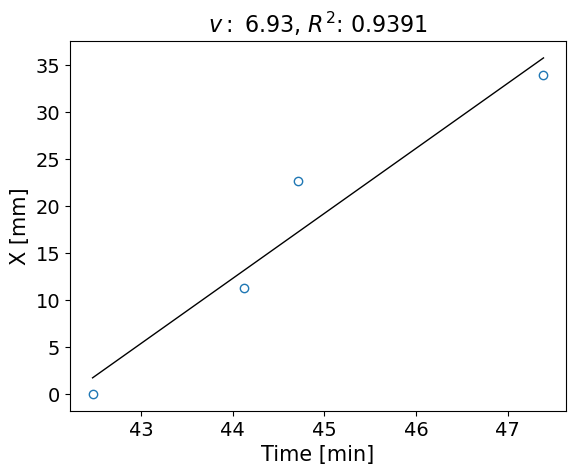

In [87]:
hmaxi = np.array(list(compute_hmax_times(results_up,np.linspace(0,205,500)).values()))
points=np.array(xi_up, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))


mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))


plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 


for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')


plt.xlabel("Time [min]",fontsize=15)
plt.ylabel("X [mm]",fontsize=15)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

fit, V=np.polyfit(hmaxi,points,1, cov=True)
relative_uncertainty = np.sqrt(V[0][0]) / fit[0]

print(fit,np.sqrt(V[0][0]),relative_uncertainty)

np.corrcoef(hmaxi, points)[0,1]**2
plt.savefig("anaupcor.pdf", format="pdf")  

In [88]:
xi_side

array([ 0.   , 11.744, 23.488, 35.23 ])

[  1.15667545 -94.33011013] 0.3369360426902931 0.2912969603577286


array([ 81.00767727,  93.57846359, 107.1155437 , 105.42716869])

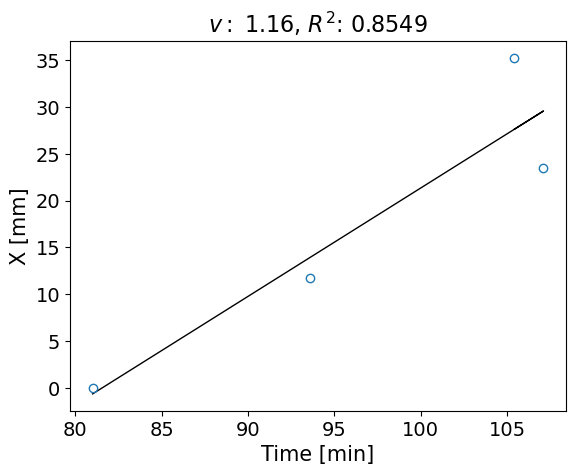

In [89]:
hmaxi = np.array(list(compute_hmax_times(results_side,np.linspace(0,205,500)).values()))
points=np.array(xi_side, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))


mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))


plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 


for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')


plt.xlabel("Time [min]",fontsize=15)
plt.ylabel("X [mm]",fontsize=15)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

fit, V=np.polyfit(hmaxi,points,1, cov=True)
relative_uncertainty = np.sqrt(V[0][0]) / fit[0]

print(fit,np.sqrt(V[0][0]),relative_uncertainty)

np.corrcoef(hmaxi, points)[0,1]**2
plt.savefig("anasidecor.pdf", format="pdf")  

hmaxi

[   4.73129145 -295.52693021] 0.2311514245814641 0.0488558836711214


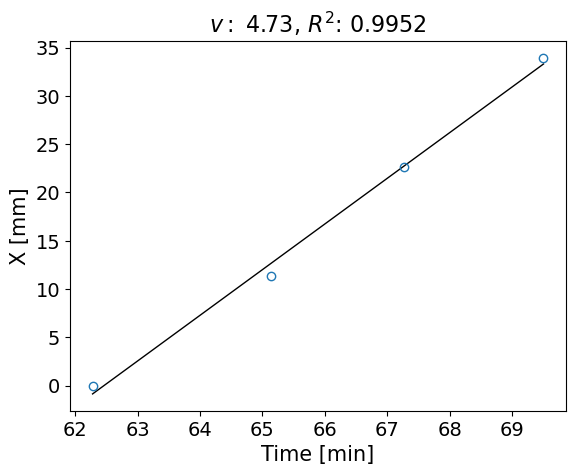

In [90]:
hmaxi = np.array(list(compute_hmax_times(results_low,np.linspace(0,205,500)).values()))
points=np.array(xi_low, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))


mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))


plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 


for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')


plt.xlabel("Time [min]",fontsize=15)
plt.ylabel("X [mm]",fontsize=15)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

fit, V=np.polyfit(hmaxi,points,1, cov=True)
relative_uncertainty = np.sqrt(V[0][0]) / fit[0]

print(fit,np.sqrt(V[0][0]),relative_uncertainty)

np.corrcoef(hmaxi, points)[0,1]**2
plt.savefig("analowcor.pdf", format="pdf")  

In [62]:
max1_up=np.max(results_up["roi1"]["cubic_spline"](np.linspace(0,140,500)))
max2_up=np.max(results_up["roi2"]["cubic_spline"](np.linspace(0,140,500)))
max3_up=np.max(results_up["roi3"]["cubic_spline"](np.linspace(0,140,500)))

max1_side=np.max(results_side["roi1"]["cubic_spline"](np.linspace(0,140,500)))
max2_side=np.max(results_side["roi2"]["cubic_spline"](np.linspace(0,140,500)))
max3_side=np.max(results_side["roi3"]["cubic_spline"](np.linspace(0,140,500)))


max1_low=np.max(results_low["roi1"]["cubic_spline"](np.linspace(0,140,500)))
max2_low=np.max(results_low["roi2"]["cubic_spline"](np.linspace(0,140,500)))
max3_low=np.max(results_low["roi3"]["cubic_spline"](np.linspace(0,140,500)))


maxi_up=[max1_up, max2_up, max3_up]
maxi_side=[max1_side, max2_side, max3_side]
maxi_low=[max1_low, max2_low, max3_low]


In [63]:
ratios_up = [maxi_up[i] / maxi_up[i + 1] for i in range(len(maxi_up) - 1)]
ratios_side = [maxi_side[i] / maxi_side[i + 1] for i in range(len(maxi_side) - 1)]
ratios_low = [maxi_low[i] / maxi_low[i + 1] for i in range(len(maxi_low) - 1)]

In [64]:
xi_up, xi_side, xi_low

(array([ 0.   , 11.313, 22.625, 33.937]),
 array([ 0.   , 11.744, 23.488, 35.23 ]),
 array([ 0.   , 11.313, 22.624, 33.927]))

In [65]:
ratios_up

[np.float64(1.1947607646243026), np.float64(1.1426715929150009)]

In [66]:
ratios_side

[np.float64(1.2240829805474003), np.float64(1.3905687716202024)]

In [67]:
ratios_low 

[np.float64(1.0809438634194328), np.float64(1.0841985519177189)]